In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
pd.set_option('display.max_columns',None)

In [3]:
# Reading the data
df = pd.read_csv("../data/raw/city_domestic.csv")

In [4]:
#Shape of the dataset
df.shape

(63173, 10)

In [5]:
# First 5 rows of the dataset
df.head()

,Year,Month,City1,City2,PaxToCity2,PaxFromCity2,FreightToCity2,FreightFromCity2,MailToCity2,MailFromCity2
0,2021,12,ADAMPUR,AHMEDABAD,30.0,0.0,0.0,0.00,0.0,0.0
1,2018,5,ADAMPUR,DELHI,2258.0,2190.0,0.0,0.86,0.0,0.0
2,2018,6,ADAMPUR,DELHI,1984.0,1981.0,0.0,4.33,0.0,0.0
3,2018,7,ADAMPUR,DELHI,2333.0,2205.0,0.0,1.93,0.0,0.0
4,2018,8,ADAMPUR,DELHI,2146.0,1981.0,0.0,0.48,0.0,0.0


In [8]:
# Datatypes in the dataset
df.dtypes

Year                  int64
Month                 int64
City1                object
City2                object
PaxToCity2          float64
PaxFromCity2        float64
FreightToCity2      float64
FreightFromCity2    float64
MailToCity2         float64
MailFromCity2       float64
dtype: object

In [9]:
# Building a date column
df['date'] = pd.to_datetime(df[['Year','Month']].assign(DAY=1))

In [10]:
df.head()

,Year,Month,City1,City2,PaxToCity2,PaxFromCity2,FreightToCity2,FreightFromCity2,MailToCity2,MailFromCity2,date
0,2021,12,ADAMPUR,AHMEDABAD,30.0,0.0,0.0,0.00,0.0,0.0,2021-12-01
1,2018,5,ADAMPUR,DELHI,2258.0,2190.0,0.0,0.86,0.0,0.0,2018-05-01
2,2018,6,ADAMPUR,DELHI,1984.0,1981.0,0.0,4.33,0.0,0.0,2018-06-01
3,2018,7,ADAMPUR,DELHI,2333.0,2205.0,0.0,1.93,0.0,0.0,2018-07-01
4,2018,8,ADAMPUR,DELHI,2146.0,1981.0,0.0,0.48,0.0,0.0,2018-08-01


In [11]:
# Aggregating the total number of passengers
df['Total_Pax'] = df['PaxToCity2'] + df['PaxFromCity2']

In [12]:
df.head()

,Year,Month,City1,City2,PaxToCity2,PaxFromCity2,FreightToCity2,FreightFromCity2,MailToCity2,MailFromCity2,date,Total_Pax
0,2021,12,ADAMPUR,AHMEDABAD,30.0,0.0,0.0,0.00,0.0,0.0,2021-12-01,30.0
1,2018,5,ADAMPUR,DELHI,2258.0,2190.0,0.0,0.86,0.0,0.0,2018-05-01,4448.0
2,2018,6,ADAMPUR,DELHI,1984.0,1981.0,0.0,4.33,0.0,0.0,2018-06-01,3965.0
3,2018,7,ADAMPUR,DELHI,2333.0,2205.0,0.0,1.93,0.0,0.0,2018-07-01,4538.0
4,2018,8,ADAMPUR,DELHI,2146.0,1981.0,0.0,0.48,0.0,0.0,2018-08-01,4127.0


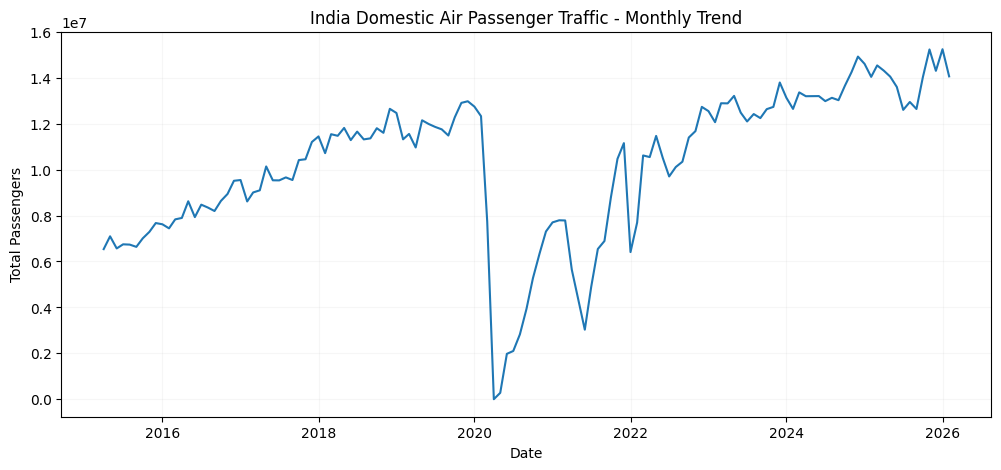

In [15]:
# Calculating and plotting the national monthly air traffic volume
national_monthly = df.groupby('date')['Total_Pax'].sum().reset_index()

plt.figure(figsize = (12,5))
plt.plot(national_monthly['date'],national_monthly['Total_Pax'])
plt.title('India Domestic Air Passenger Traffic - Monthly Trend')
plt.xlabel('Date')
plt.ylabel('Total Passengers')
plt.grid(alpha = 0.1)
plt.show()
